In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

TRAIN_PATH = "train.csv"  
TEST_PATH  = "test.csv" 

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

LEARNING_RATE = 0.001   
EPOCHS = 700

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (283085, 19)
Test shape: (177063, 19)


In [2]:
TARGET_COL = "close"

possible_cols = [
    "open", "high", "low", "volume",
    "momentum_index", "beta_indicator", "risk_premium",
     "technical_score","close"
]

FEATURE_COLS = [c for c in possible_cols if c != TARGET_COL]

In [3]:
cols_needed = FEATURE_COLS + [TARGET_COL]
df = train_df[cols_needed].copy()

for c in cols_needed:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(axis=0).reset_index(drop=True)

testX = test_df[FEATURE_COLS].copy()
for c in FEATURE_COLS:
    testX[c] = pd.to_numeric(testX[c], errors='coerce')

train_means = df[FEATURE_COLS].mean()
testX = testX.fillna(train_means)

In [4]:
X_train = df[FEATURE_COLS].values.astype(float)
y_train = df[TARGET_COL].values.astype(float).reshape(-1, 1)  
X_test  = testX[FEATURE_COLS].values.astype(float)

X_mean = X_train.mean(axis=0, keepdims=True)
X_std  = X_train.std(axis=0, keepdims=True) + 1e-8  

X_train_std = (X_train - X_mean) / X_std
X_test_std  = (X_test  - X_mean) / X_std

m, n = X_train_std.shape

In [5]:
def mse(y_true, y_pred):
    diff = y_pred - y_true
    return float(np.mean(diff**2))

def r2_score(y_true, y_pred):
    y_true = y_true.reshape(-1, 1)
    y_pred = y_pred.reshape(-1, 1)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2) + 1e-12
    return float(1 - ss_res/ss_tot)

In [6]:
def predict(X, w, b):
    return X @ w + b

def compute_gradients(X, y, w, b):
    m = X.shape[0]
    y_hat = predict(X, w, b)
    residual = (y_hat - y)  
    dw = (2.0/m) * (X.T @ residual)  
    db = (2.0/m) * np.sum(residual) 
    return dw, db

def initialize_params(n_features):
    w = np.zeros((n_features, 1))
    b = 0.0
    return w, b

w, b = initialize_params(n)

train_mse_hist, test_mse_hist = [], []
train_r2_hist,  test_r2_hist  = [], []

for epoch in range(1, EPOCHS+1):
    y_hat_train = predict(X_train_std, w, b)
    
    train_mse_val = mse(y_train, y_hat_train)
    train_r2_val  = r2_score(y_train, y_hat_train)
    train_mse_hist.append(train_mse_val)
    train_r2_hist.append(train_r2_val)
    
    dw, db = compute_gradients(X_train_std, y_train, w, b)
    w -= LEARNING_RATE * dw
    b -= LEARNING_RATE * db
    
    test_mse_hist.append(np.nan)
    test_r2_hist.append(np.nan)
    
    if epoch % max(1, EPOCHS//10) == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | Train MSE: {train_mse_val:.4f} | Train R^2: {train_r2_val:.4f}")
        
print("Training complete.")


Epoch    1 | Train MSE: 9840.5843 | Train R^2: -0.7392
Epoch   70 | Train MSE: 5885.2206 | Train R^2: -0.0402
Epoch  140 | Train MSE: 3964.5829 | Train R^2: 0.2993
Epoch  210 | Train MSE: 2929.6921 | Train R^2: 0.4822
Epoch  280 | Train MSE: 2300.3993 | Train R^2: 0.5934
Epoch  350 | Train MSE: 1880.3074 | Train R^2: 0.6677
Epoch  420 | Train MSE: 1582.3877 | Train R^2: 0.7203
Epoch  490 | Train MSE: 1363.5247 | Train R^2: 0.7590
Epoch  560 | Train MSE: 1199.5026 | Train R^2: 0.7880
Epoch  630 | Train MSE: 1075.1166 | Train R^2: 0.8100
Epoch  700 | Train MSE: 980.0244 | Train R^2: 0.8268
Training complete.


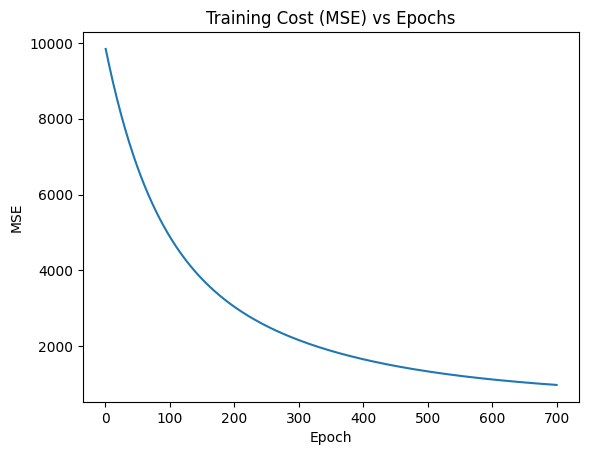

In [7]:
plt.plot(range(1, EPOCHS+1), train_mse_hist)
plt.title("Training Cost (MSE) vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

In [8]:
y_train_pred = predict(X_train_std, w, b)

comparison_train = pd.DataFrame({
    "Actual_Close": y_train.flatten(),
    "Predicted_Close": y_train_pred.flatten()
})
display(comparison_train.head(15))  


,Actual_Close,Predicted_Close
0,27.410000,52.715861
1,25.230000,53.053912
2,30.000000,-59.583787
3,68.480003,31.937701
4,43.209999,18.114986
5,64.430000,74.495158
6,39.849998,56.599101
7,7.075000,10.230615
8,72.010002,30.517449
9,66.720001,38.324140


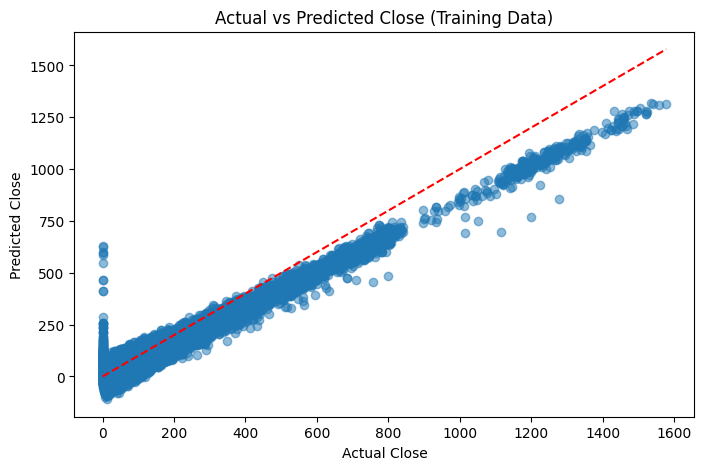

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(y_train, y_train_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')  
plt.xlabel("Actual Close")
plt.ylabel("Predicted Close")
plt.title("Actual vs Predicted Close (Training Data)")
plt.show()


In [10]:
train_pred = predict(X_train_std, w, b)
test_pred = predict(X_test_std,w,b)
train_rmse = np.sqrt(mse(y_train, train_pred))
train_r2 = r2_score(y_train, train_pred)

print(f"Training RMSE: {train_rmse:.4f}")
print(f"Training R²: {train_r2:.4f}")

if TARGET_COL in test_df.columns:
    y_test_clean = test_df[TARGET_COL].dropna().values.reshape(-1,1)
    test_pred_clean = test_pred[~np.isnan(test_df[TARGET_COL])].reshape(-1,1)
    test_rmse = np.sqrt(mse(y_test_clean, test_pred_clean))
    test_r2 = r2_score(y_test_clean, test_pred_clean)
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Test R²: {test_r2:.4f}")

Training RMSE: 31.2864
Training R²: 0.8270
Test RMSE: 32.5149
Test R²: 0.8139
